## Experiment Controls

In [1]:
STATE_NAME = 'colorado'
ACCEPT_STRATEGY_NAME = 'neutral' # 'neutral', 'optimized', 'unoptimized'
WEIGHTS_FILE = 'test_weights'
MARKOV_STEPS = 2000
DESIRED_TCP = 0.8

In [2]:
# Parameters
STATE_NAME = "colorado"
ACCEPT_STRATEGY_NAME = "optimized_cs"
WEIGHTS_FILE = "test_weights"
MARKOV_STEPS = 10000
DESIRED_TCP = 0.85


## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import sys
import os
# go up a level to main proj folder
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from common import scoring
from common import plotting
from common import acceptance

In [4]:

from IPython.display import display

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import pearsonr
import networkx as nx

from gerrychain import (Partition, Graph, MarkovChain, accept)
from gerrychain.accept import always_accept
from gerrychain.proposals import recom
from gerrychain.updaters import cut_edges
from gerrychain.tree import recursive_tree_part
from functools import partial

import json

## Process Initial Data

### Census-Level Precinct Data + Community Data

In [5]:
vtds = gpd.read_file("data/co.shp")
cois = gpd.read_file("data/Colorado_communities_labeled.geojson")

# align coords
if cois.crs != vtds.crs:
    vtds = vtds.to_crs(cois.crs)

# get total presidential election 2020 vote pop
vtds['TOTVOTES20'] = vtds['PRE20D'] + vtds['PRE20R'] + vtds['PRE20O']

# calculate coi fractions per vtd
vtds['vtd_area'] = vtds.geometry.area

overlaps = gpd.overlay(vtds, cois, how='intersection')
overlaps['coi_fraction'] = overlaps.geometry.area / overlaps['vtd_area']

# drop tiny overlaps
clean_overlaps = overlaps[overlaps['coi_fraction'] > 0.01].copy()
clean_overlaps['coi_pop'] = clean_overlaps['TOTPOP'] * clean_overlaps['coi_fraction']

# build coi pop dict per vtd - Note: CO uses 'entry_ID' instead of 'cluster'
coi_dict = {}
for index, row in clean_overlaps.iterrows():
    vtd_name = row['NAME20']
    cluster_id = row['entry_ID']
    population_chunk = row['coi_pop']
    
    if vtd_name not in coi_dict:
        coi_dict[vtd_name] = {}
        
    coi_dict[vtd_name][cluster_id] = {
        'pop': population_chunk,
        'category': row.get('predicted_category', 'coi')
    }

vtds['COI_POPS'] = [coi_dict.get(name, {}) for name in vtds['NAME20']]

C:\Users\gislab\AppData\Local\Temp\ipykernel_11408\240197566.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  vtds['vtd_area'] = vtds.geometry.area


C:\Users\gislab\AppData\Local\Temp\ipykernel_11408\240197566.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  overlaps['coi_fraction'] = overlaps.geometry.area / overlaps['vtd_area']


### Add District Data from Congressional Map - 2021

In [6]:
congressional_2021 = gpd.read_file("data/2021_Approved_Congressional_Plan_with_Final_Adjustments/2021_Approved_Congressional_Plan_with_Final_Adjustments/2021_Approved_Congressional_Plan_w_Final_Adjustments.shp")
congressional_2021 = congressional_2021.to_crs(vtds.crs)

# map vtd points to congressional districts
vtd_points = vtds.copy()
vtd_points.geometry = vtd_points.representative_point()
joined_vtds_2021 = gpd.sjoin(vtd_points, congressional_2021, how="left", predicate="intersects")
vtds['district_2021'] = joined_vtds_2021['District']

## Markov Chaining

### Init Graph and Chain

In [7]:
vtds.geometry = vtds.geometry.buffer(0)
g = Graph.from_geodataframe(vtds)

with open(f'../weights/{WEIGHTS_FILE}.json', 'r') as f:
    state_weights = json.load(f)

g.graph['DESIRED_TCP'] = DESIRED_TCP
g.graph['WEIGHT_MAP'] = state_weights

# colorado has 8 congressional districts
total_population = sum(node.get('TOTPOP', 1) for node in g.nodes.values())
target_pop = total_population / 8

starting_assignment = recursive_tree_part(
    g, 
    parts=range(8), 
    pop_target=target_pop, 
    pop_col="TOTPOP", 
    epsilon=0.05
)

updaters_dict = { 
    'raw_df': scoring.extract_data, 
    'unweighted_tcp_score': scoring.calculate_unweighted_tcp,
    'weighted_tcp_score': scoring.calculate_weighted_tcp,
    'communities_split': scoring.communities_split,
    'effective_splits': scoring.effective_splits,
    'sr_entropy': scoring.square_root_entropy,
    'shannon_entropy': scoring.shannon_entropy,
    'even_splits': scoring.even_splits,
    'cut_edges': cut_edges,
    'dem_wins': scoring.count_dem_wins,
    'dem_share': scoring.dem_share,
    'dem_box': scoring.dem_boxes
}

initial_partition = Partition(
    g, 
    assignment=starting_assignment, 
    updaters=updaters_dict
)

proposal = partial(recom, pop_col="TOTPOP", pop_target=target_pop, epsilon=0.05, node_repeats=2)
accept_function = acceptance.STRATEGIES.get(ACCEPT_STRATEGY_NAME, always_accept)

chain = MarkovChain(
    proposal=proposal,
    constraints=[],
    accept=accept_function,
    initial_state=initial_partition,
    total_steps=MARKOV_STEPS
)

C:\Users\gislab\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\gerrychain\graph\graph.py:266: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = df.geometry.area.to_dict()


### Run Chain

In [8]:
num_districts = len(initial_partition.parts)

chain_results = {
    'step': [],
    'weighted_tcp_score': [],
    'unweighted_tcp_score': [],
    'communities_split': [],
    'effective_splits': [],
    'sr_entropy': [],
    'shannon_entropy': [],
    'even_splits': [],
    'cut_edges': [],
    'dem_wins': []
}
for i in range(1, num_districts + 1):
    chain_results[f'dist_{i}_dem_share'] = []

best_score, worst_score, most_seats = 0, 1, 0
best_map, worst_map, overall_best_map = None, None, None

for step, partition in enumerate(chain):
    if step > 0 and step % (MARKOV_STEPS // 10 or 1) == 0:
        # TODO: save every mod 10.000 partitions
        print(f"completed {step} steps...")

    weighted_score = partition['weighted_tcp_score']
    seats = partition['dem_wins']
    shares = partition['dem_share']

    chain_results['step'].append(step)
    chain_results['weighted_tcp_score'].append(weighted_score)
    chain_results['unweighted_tcp_score'].append(partition['unweighted_tcp_score'])
    chain_results['communities_split'].append(partition['communities_split'])
    chain_results['effective_splits'].append(partition['effective_splits'])
    chain_results['sr_entropy'].append(partition['sr_entropy'])
    chain_results['shannon_entropy'].append(partition['shannon_entropy'])
    chain_results['even_splits'].append(partition['even_splits'])
    chain_results['cut_edges'].append(len(partition['cut_edges']))
    chain_results['dem_wins'].append(seats)
    for i in range(num_districts):
        chain_results[f'dist_{i+1}_dem_share'].append(shares[i])

    if weighted_score > best_score:
        best_score = weighted_score
        best_map = partition

    if weighted_score < worst_score:
        worst_score = weighted_score
        worst_map = partition

    if seats > most_seats or (seats == most_seats and weighted_score > overall_best_score):
        most_seats = seats
        overall_best_score = weighted_score
        overall_best_map = partition

# save results
#TODO: batch saves
results_df = pd.DataFrame(chain_results)

k_str = f"{int(MARKOV_STEPS/1000)}k" if MARKOV_STEPS >= 1000 else str(MARKOV_STEPS)
base_filename = f"data/{STATE_NAME}_{ACCEPT_STRATEGY_NAME}_{WEIGHTS_FILE}_{k_str}"
csv_filename = f"{base_filename}.csv"

version = 1
while os.path.exists(csv_filename):
    csv_filename = f"{base_filename}_v{version}.csv"
    version += 1

results_df.to_csv(csv_filename, index=False)
print(f"saved chain data to: {csv_filename}")

2
2


1
1
6


6
7


3
3
32
2


1
2


...

1
6
0
0


0
9


20
0
0
0


0
0


13
saved chain data to: data/colorado_optimized_cs_test_weights_10k.csv


## Maps

In [9]:
enacted_2021 = Partition(
    g,
    assignment="district_2021",
    updaters=updaters_dict
)

In [10]:
plotting.plot_partition_detailed(enacted_2021, vtds, cois, title="2021 Enacted Map", cluster_col="entry_ID")
plotting.plot_partition_detailed(best_map, vtds, cois, title="Most Preserved Map", cluster_col="entry_ID")
plotting.plot_partition_detailed(worst_map, vtds, cois, title="Worst Preserved Map", cluster_col="entry_ID")

## Plots

In [11]:
enacted_reference_data = {
    "2021 Enacted": {
        "score": enacted_2021["weighted_tcp_score"], 
        "wins": enacted_2021["dem_wins"]
    }
}

initial_score = initial_partition["weighted_tcp_score"]
initial_wins = initial_partition["dem_wins"]

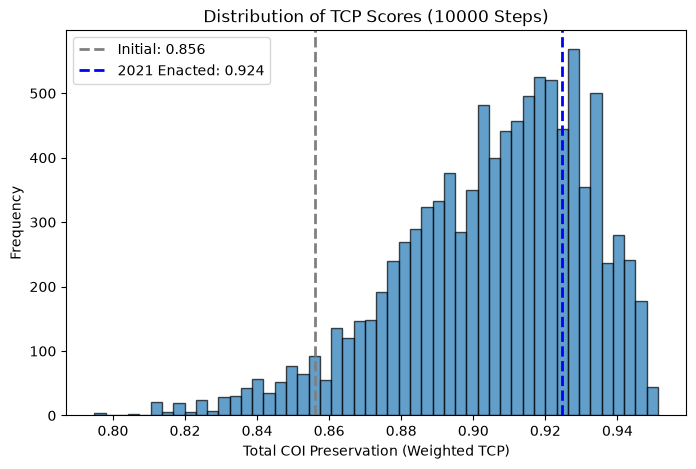

In [12]:
plotting.plot_tcp_distribution(
    results_df, 
    initial_score=initial_score, 
    enacted_data=enacted_reference_data, 
    steps_str=str(MARKOV_STEPS)
)

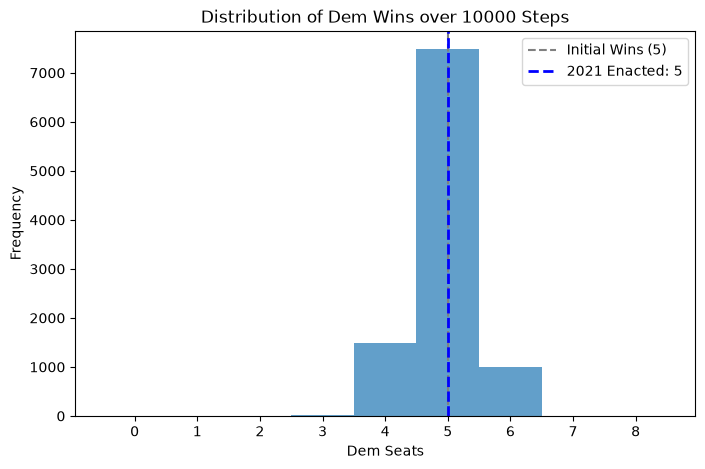

In [13]:
plotting.plot_dem_wins_distribution(
    results_df, 
    initial_wins=initial_wins, 
    enacted_data=enacted_reference_data, 
    steps_str=str(MARKOV_STEPS)
)

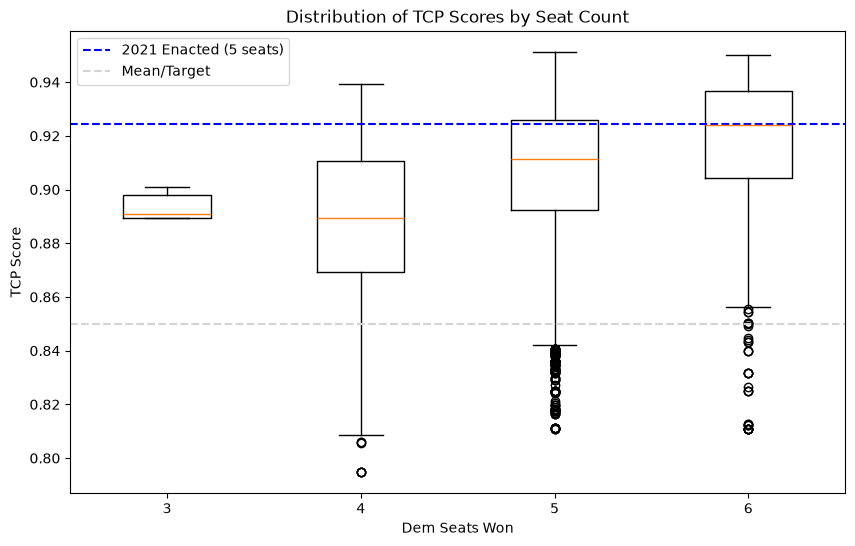

In [14]:
plotting.plot_tcp_by_seat_count(
    results_df, 
    enacted_data=enacted_reference_data, 
    desired_tcp=DESIRED_TCP
)

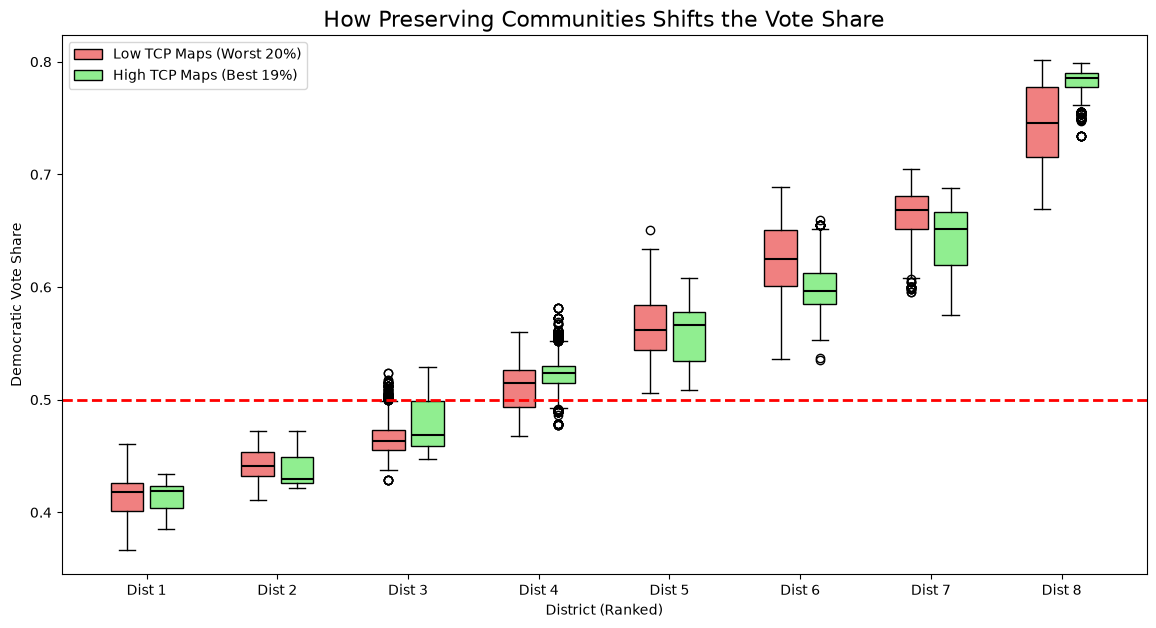

In [15]:
plotting.plot_partisan_shift(
    results_df, 
    score_col='weighted_tcp_score', 
    top_q=0.80, 
    bottom_q=0.20
)

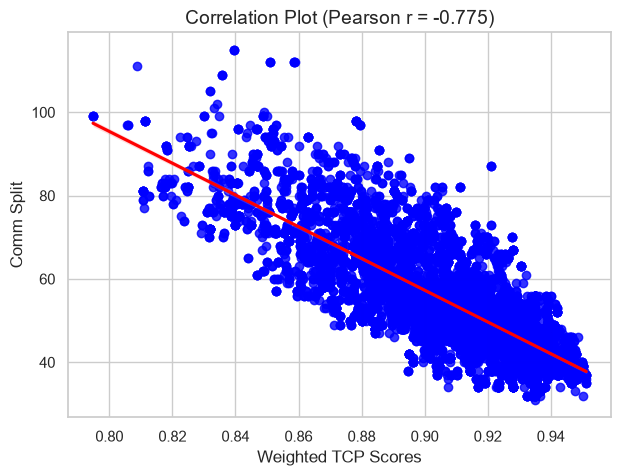

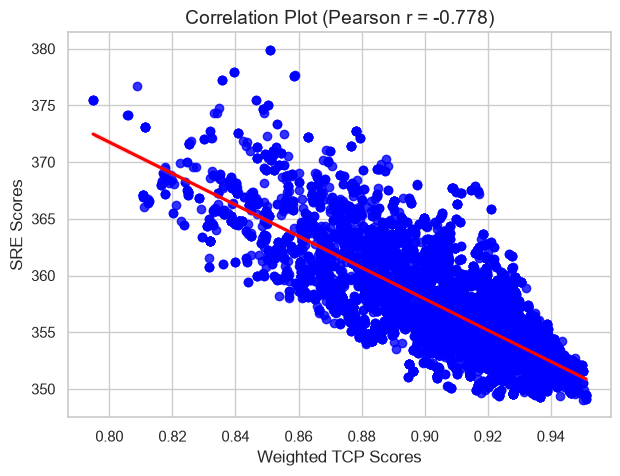

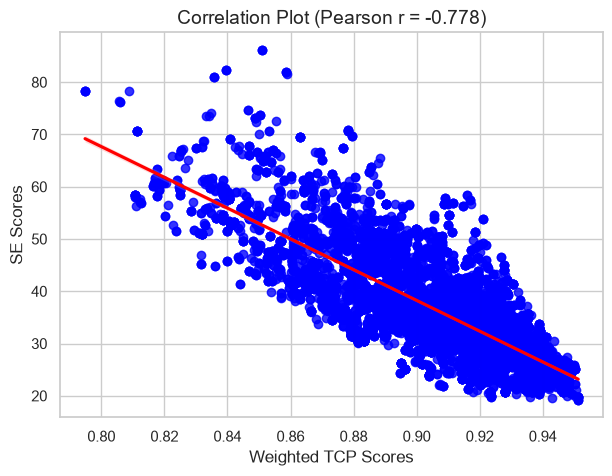

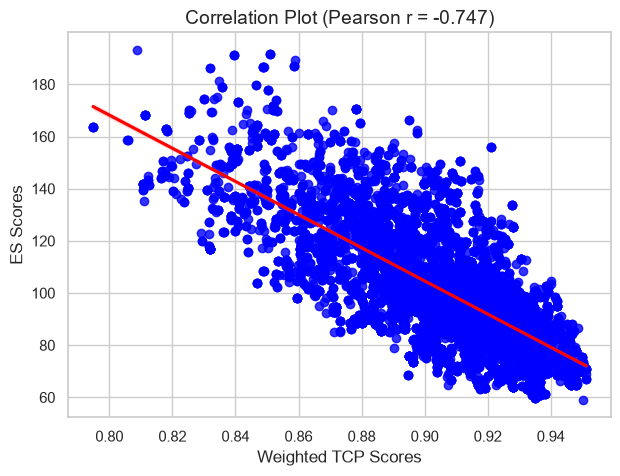

In [16]:

## correlation scatters
metrics_to_correlate = [
    ('communities_split', 'Comm Split'),
    ('sr_entropy', 'SRE Scores'),
    ('shannon_entropy', 'SE Scores'),
    ('even_splits', 'ES Scores')
]

sns.set_theme(style="whitegrid")
for metric_col, label in metrics_to_correlate:
    corr_coef, _ = pearsonr(results_df['weighted_tcp_score'], results_df[metric_col])
    
    plt.figure(figsize=(7, 5))
    sns.regplot(
        data=results_df, 
        x='weighted_tcp_score', 
        y=metric_col, 
        scatter_kws={"color": "blue"}, 
        line_kws={"color": "red"}, 
        marker="o"
    )
    plt.title(f"Correlation Plot (Pearson r = {corr_coef:.3f})", fontsize=14)
    plt.xlabel("Weighted TCP Scores")
    plt.ylabel(label)
    plt.show()